# Sowing Success: How Machine Learning Helps Farmers Select the Best Crops

![Farmer in a field](farmer_in_a_field.jpg)

Measuring essential soil metrics such as nitrogen, phosphorous, potassium levels, and pH value is an important aspect of assessing soil condition. However, it can be an expensive and time-consuming process, which can cause farmers to prioritize which metrics to measure based on their budget constraints.

Farmers have various options when it comes to deciding which crop to plant each season. Their primary objective is to maximize the yield of their crops, taking into account different factors. One crucial factor that affects crop growth is the condition of the soil in the field, which can be assessed by measuring basic elements such as nitrogen and potassium levels. Each crop has an ideal soil condition that ensures optimal growth and maximum yield.

A farmer reached out to you as a machine learning expert for assistance in selecting the best crop for his field. They've provided you with a dataset called `soil_measures.csv`, which contains:

- `"N"`: Nitrogen content ratio in the soil
- `"P"`: Phosphorous content ratio in the soil
- `"K"`: Potassium content ratio in the soil
- `"pH"` value of the soil
- `"crop"`: categorical values that contain various crops (target variable).

Each row in this dataset represents various measures of the soil in a particular field. Based on these measurements, the crop specified in the `"crop"` column is the optimal choice for that field.  

In this project, you will build multi-class classification models to predict the type of `"crop"` and identify the single most importance feature for predictive performance.

Business Objective: Predict which crop will obtain the highest yield, given the best soil metric

Due to constraints, the goal is to identify the most important metric among the current soil metrics being tracked. The most important soil metric will have the best performance in predicting crop yields for the crops field contained in the dataset.

The project instructions outline that we are classfying the crop that will output the highest yield, given soil metrics. 

In [29]:
# All required libraries are imported here for you.
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

# Load the dataset
crops = pd.read_csv("soil_measures.csv")

# Inspect DataFrame -- check column names and data types
crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [30]:
crops.shape

(2200, 5)

In [31]:
# Check for nulls -- none so DataFrame is ready for use!
crops.isna().sum()

N       0
P       0
K       0
ph      0
crop    0
dtype: int64

In [32]:
#Identify crop types
crops["crop"].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [33]:
crops.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


In [34]:
# Split into feature and target sets
X = crops.drop(columns="crop")
y = crops["crop"]

In [35]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30
)


In [36]:
# Create a dictionary to store the model performance for each feature
feature_performance = {}

# Train a logistic regression model for each feature
for feature in ["N", "P", "K", "ph"]:
    log_reg = LogisticRegression(multi_class="multinomial")
    log_reg.fit(X_train[[feature]], y_train)
    y_pred = log_reg.predict(X_test[[feature]])
    y_pred_probs = log_reg.predict_log_proba(X_test[[feature]])[:,1]
    
    # Calculate F1 score, the harmonic mean of precision and recall
    # Could also use balanced_accuracy_score
    f1 = metrics.f1_score(y_test, y_pred, average="weighted")
    #balanced_score = metrics.balanced_accuracy_score(y_test,y_pred)
    # Add feature-f1 score pairs to the dictionary
    feature_performance[feature] = f1
    print(f"F1-score for {feature}: {f1}")
    #print(f"Balanced Accuracy Score for {feature}: {balanced_score}")

F1-score for N: 0.09947751159500368
F1-score for P: 0.1433335293421065
F1-score for K: 0.2586060111598102
F1-score for ph: 0.050888067273224556


In [37]:
# K produced the best F1 score
# Store in best_predictive_feature dictionary
best_predictive_feature = {"K": feature_performance["K"]}
best_predictive_feature

{'K': 0.2586060111598102}

Looking at model predictions by running and plotting regression **results**

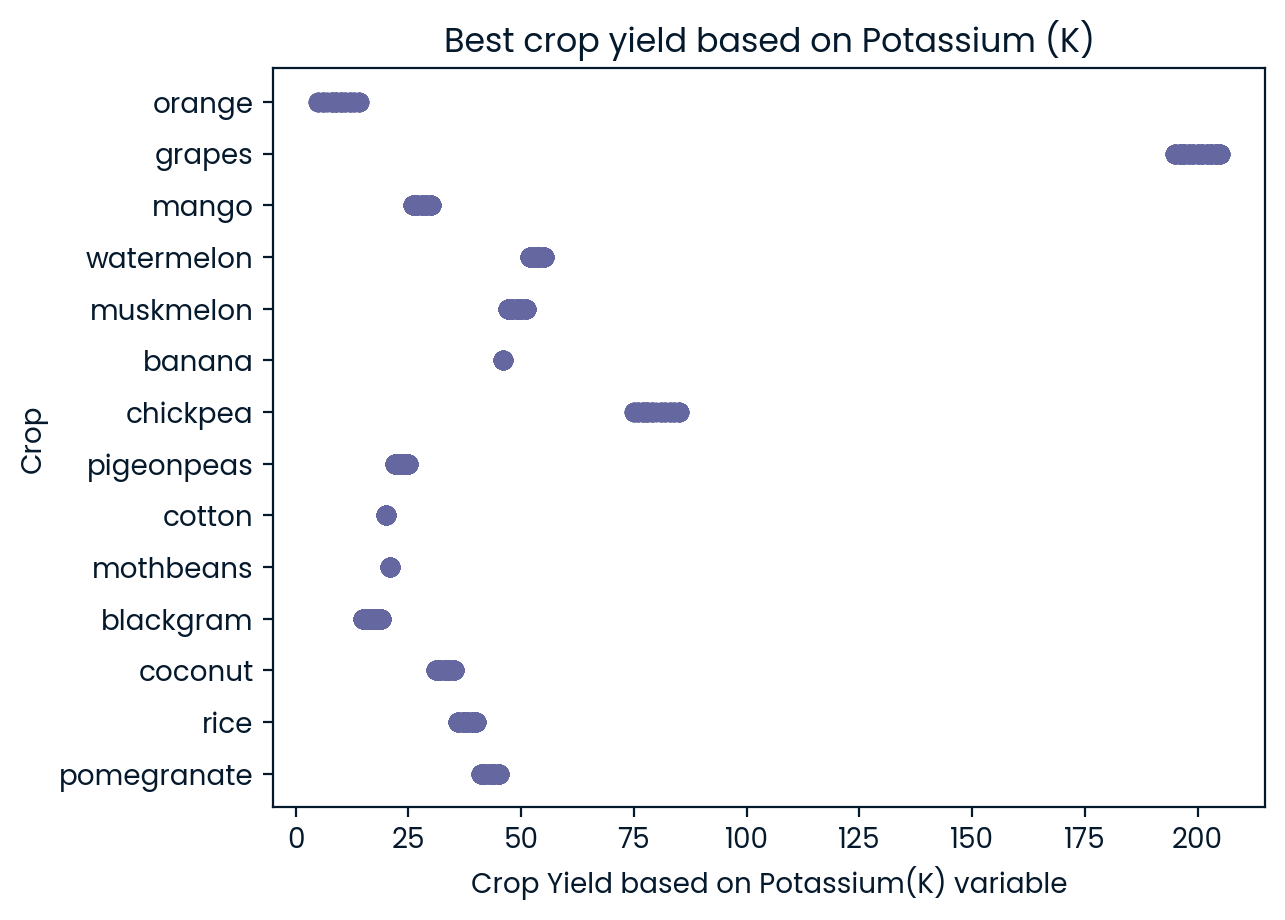

In [38]:
X_ = crops.drop("crop", axis=1).values
y_ = crops["crop"].values
X_varK = X_[: ,2]
X_varK = X_varK.reshape(-1,1)

log_reg.fit(X_varK, y_)
y_pred_ = log_reg.predict(X_varK)
plt.scatter(X_varK, y_pred_)
plt.title("Best crop yield based on Potassium (K)")
plt.ylabel("Crop")
plt.xlabel("Crop Yield based on Potassium(K) variable")
plt.show()